In [1]:
# %load_ext autoreload
# %autoreload 2

# Import libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif, chi2
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.tree import export_graphviz
from IPython.display import Image
from subprocess import call
import warnings
warnings.filterwarnings("ignore")
import os
import sys
sys.path.insert(0, os.path.abspath('../'))
from visualize_py import plot_confusion_matrix, plot_roc_curve, plot_feature_importance, \
    plot_feature_importance_log, plot_feature_importance_dec, plotVar, plotAge, plotContinuous, plotCategorical
from IPython.core.display import HTML as Center

Center(""" <style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style> """)

<div class="alert alert-block alert-info">
<b>Load data</b>
</div>

In [2]:
# Import data
df = pd.read_csv('../input/uci-heart-disease-data-set/processed.cleveland.data', header = None, 
                 names = ['age', 'sex', 'chest_pain_type', 'rest_blood_press', 'cholesterol',
                          'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 
                          'exer_ind_angina', 'st_depression', 'st_slope',                                                                                                         'num_major_vessels', 'thallium_scint', 'ca_disease'], 
                 index_col=None, usecols = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], 
                 sep=',', skipinitialspace=True)
df.head(20)
print(df.shape)

,age,sex,chest_pain_type,rest_blood_press,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exer_ind_angina,st_depression,st_slope,num_major_vessels,thallium_scint,ca_disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


(303, 14)


The dataset read from csv file has 303 rows and 14 columns.
The data dictionary specified that 303 rows and 75 columns existed.
We therefore have the same number of rows as the data dictionary, but 61 fewer columns...

We were lucky that the data was already pre-processed, and this can be observed from the subset of data displayed
appearing very clean. Hopefully not much further cleaning would be required.

The original field names were not very informative. We therefore renamed the fields based on information gathered
from the article by Detrano et al.

Let us explore the data!

<div class="alert alert-block alert-info">
<b>Clean data</b>
</div>

In [3]:
# Type of data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    float64
 1   sex                  303 non-null    float64
 2   chest_pain_type      303 non-null    float64
 3   rest_blood_press     303 non-null    float64
 4   cholesterol          303 non-null    float64
 5   fasting_blood_sugar  303 non-null    float64
 6   rest_ecg             303 non-null    float64
 7   max_heart_rate       303 non-null    float64
 8   exer_ind_angina      303 non-null    float64
 9   st_depression        303 non-null    float64
 10  st_slope             303 non-null    float64
 11  num_major_vessels    303 non-null    object 
 12  thallium_scint       303 non-null    object 
 13  ca_disease           303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None


From the output we observe that we have twelve numeric columns and two "object" columns. The data dictionary
however specifies that all fields are numeric. This means that Python could not convert two numeric variables
(num_major_vessels and thallium_scint) to numeric columns due to their contents being non-numeric. Let us investigate.

In [4]:
# Find out what types of data is stored in object column. Use simple regex. Leading number omitted not catered for.
# Future improvement.
r = re.compile(r'\d+[.,]\d*')
df.num_major_vessels.apply(lambda x: bool(r.match(x))).value_counts()
df.thallium_scint.apply(lambda x: bool(r.match(x))).value_counts()

df.loc[df.num_major_vessels.apply(lambda x: bool(r.match(x))) == False]
df.loc[df.thallium_scint.apply(lambda x: bool(r.match(x))) == False]

True     299
False      4
Name: num_major_vessels, dtype: int64

True     301
False      2
Name: thallium_scint, dtype: int64

,age,sex,chest_pain_type,rest_blood_press,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exer_ind_angina,st_depression,st_slope,num_major_vessels,thallium_scint,ca_disease
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


,age,sex,chest_pain_type,rest_blood_press,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exer_ind_angina,st_depression,st_slope,num_major_vessels,thallium_scint,ca_disease
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2


We can see that there are 4 non-numeric fields in num_major_vessels and 2 in thallium_scint. These values are all '?'.
It is a reasonable assumption that these are missing values from data entry due to the placeholder. We will therefore
clean the data by replacing these values with NaN and converting all character values to decimal.

In [5]:
# Replace all non numeric data with NaN, convert strings to numbers.
df_clean = df.apply(pd.to_numeric, errors='coerce')

Let us see if that worked! We should now have only decimal and null values.

In [6]:
# Number of null values
print(df_clean.isnull().sum())

# Actual null values
df_clean[df_clean.isnull().any(axis=1)]

age                    0
sex                    0
chest_pain_type        0
rest_blood_press       0
cholesterol            0
fasting_blood_sugar    0
rest_ecg               0
max_heart_rate         0
exer_ind_angina        0
st_depression          0
st_slope               0
num_major_vessels      4
thallium_scint         2
ca_disease             0
dtype: int64


,age,sex,chest_pain_type,rest_blood_press,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exer_ind_angina,st_depression,st_slope,num_major_vessels,thallium_scint,ca_disease
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


Looks great we have 6 null values, 4 in num_major_vessels and 2 in thallium_scint as expected. We can also observe
that none of the other fields contain any null values. Seeing as there are only a handful of these values and none
in the response variable, it is not necessary to remove these records from the dataset at this stage.

We now have a dataset with 303 records and 14 numeric fields, as per the data dictionary, there are still 6 missing
values in the 'num_major_vessels' and 'thallium_scint' fields though. Due to the low number of missing values and even
distribution of values in these fields (see explore analysis below) we will now substitute these with median values.

In [7]:
df_fin = df_clean.copy()
median = df_fin['num_major_vessels'].median()
df_fin['num_major_vessels'].fillna(median, inplace=True)
print("Number of null values in num_major_vessels column: {}".format(df_fin['num_major_vessels'].isnull().sum()))

median = df_fin['thallium_scint'].median()
df_fin['thallium_scint'].fillna(median, inplace=True)
print("Number of null values in thallium_scint column: {}".format(df_fin['thallium_scint'].isnull().sum()))
print("Dataframe dimension: {}".format(df_fin.shape))

Number of null values in num_major_vessels column: 0
Number of null values in thallium_scint column: 0
Dataframe dimension: (303, 14)


Now our set is finally ready for further analysis. We will now look at the distribution of variables and any possible
outliers or heavy tailed distributions.

<div class="alert alert-block alert-info">
<b>Explore data</b>
</div>

We start by looking at the number of unique records per variable.

In [8]:
print(df_fin.nunique())

age                     41
sex                      2
chest_pain_type          4
rest_blood_press        50
cholesterol            152
fasting_blood_sugar      2
rest_ecg                 3
max_heart_rate          91
exer_ind_angina          2
st_depression           40
st_slope                 3
num_major_vessels        4
thallium_scint           3
ca_disease               5
dtype: int64


There are no columns with only one value. We therefore retain all columns for ML purposes as there is enough
variability to warrant using the data. Interesting to observe that there is also a fair amount of similarity in
the cholesterol measurements which is surprising. There are many variables with fewer than 10 levels which
could be considered as categorical. Based on our initial assessment of the data we will work with levels of measurement
for the data as follows:

- age (continuous)
- sex (binary)
- chest_pain_type (ordinal)
- rest_blood_press (continuous)
- cholesterol (continuous)
- fasting_blood_sugar (binary)
- rest_ecg (ordinal)
- max_heart_rate (continuous)
- exer_ind_angina (binary)
- st_depression (continuous)
- st_slope (ordinal)
- num_major_vessels (ordinal)
- thallium_scint (ordinal - needs reordering)
- ca_disease (binary - we will need to transform as there are actually 5 levels in the data)

At this point it seems as if the only nominal data is binary, which means we might not need any One Hot Encoding
initially. We will leave the ordinal data as is for the initial analysis.
Next we look at the distribution of the data.

We now extract data according levels of measurement first to ease analysis. We also rename the variables to enable
ease of interpretion.

In [9]:
# Extract categorical variables for analysis.
df_fin_cat = df_fin.copy()
names_cat = ('sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exer_ind_angina', 'st_slope',
             'num_major_vessels', 'thallium_scint', 'ca_disease')
df_fin_cat = df_fin_cat.loc[:, names_cat]

# Extract continuous variables for analysis.
#df_fin.reset_index(drop=True, inplace=True)
df_fin_con = df_fin.copy()
names_con = ('age', 'rest_blood_press', 'cholesterol', 'max_heart_rate', 'st_depression')
df_fin_con = df_fin_con.loc[:, names_con]

# Plotting label dictionary
plot_cat = [('sex', ['female', 'male']),
              ('chest_pain_type', ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic']),
              ('fasting_blood_sugar', ['fbs > 120mg', 'fbs < 120mg']),
              ('rest_ecg', ['normal', 'ST T-wave', 'left ventricular']),
              ('exer_ind_angina', ['yes', 'no']),
              ('st_slope', ['upsloping', 'flat', 'downsloping']),
              ('num_major_vessels', ['0', '1', '2', '3']),
              ('thallium_scint', ['normal', 'fixed defect', 'reversible defect']),
              ('ca_disease', ['No CA disease', 'CA disease'])]
plot_con = [('age', 'age in years'),
            ('rest_blood_press', 'blood pressure in mm Hg'),
              ('cholesterol', 'serum cholesterol in mg/d'),
              ('max_heart_rate', 'maximum heart rate achieved'),
              ('st_depression', 'ST depression by exercise relative to rest'),
              ('ca_disease', 'Coronary Artery disease')]

# Extract numeric variables for analysis.
df_fin.reset_index(drop=True, inplace=True)
df_fin_num = df_fin.copy()
names_num = ('age', 'sex', 'chest_pain_type', 'rest_blood_press', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
             'max_heart_rate', 'exer_ind_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thallium_scint',
             'ca_disease')
df_fin_num = df_fin_num.loc[:, names_num]

Now let us consider the response variable.

0    164
1     55
2     36
3     35
4     13
Name: ca_disease, dtype: int64


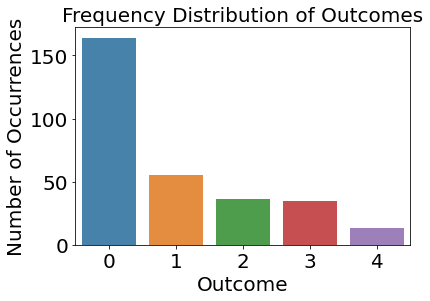

In [10]:
#outcome_counts = df_fin_cat.groupby('ca_disease').size()
outcome_counts = df_fin_cat['ca_disease'].value_counts()
print(outcome_counts)

# Plot outcome counts.
ax = sns.barplot(x=outcome_counts.index, y=outcome_counts.values, alpha=0.9)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
#ax.title.set_size(45)
ax.tick_params('y', labelsize = 20);
ax.tick_params('x', labelsize = 20);
plt.title('Frequency Distribution of Outcomes', fontsize=20)
plt.ylabel('Number of Occurrences')
plt.xlabel('Outcome')
plt.show();

All looks good here. No obvious issues with the data. The spread of the data is good for classification, as there are
a large number of positive cases. If one combines classes 1, 2, 3 and 4 as suggested there will be a fairly even split
between positive and negative outcomes.
Let us look at that.

0    164
1    139
Name: num_bin, dtype: int64


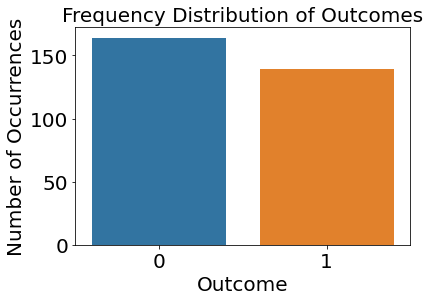

In [11]:
# Transform y variable
df_fin_cat['num_bin'] = df_fin['ca_disease'].apply(lambda x: 1 if x > 0 else 0)

outcome_counts_bin = df_fin_cat['num_bin'].value_counts()
print(outcome_counts_bin)
ax = sns.barplot(x=outcome_counts_bin.index, y=outcome_counts_bin.values)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
#ax.title.set_size(45)
ax.tick_params('y', labelsize = 20);
ax.tick_params('x', labelsize = 20);
plt.title('Frequency Distribution of Outcomes', fontsize = 20)
plt.ylabel('Number of Occurrences')
plt.xlabel('Outcome')
plt.show();

As expected, we don't need to be concerned about imbalanced classes for this analysis.

Let us now consider the categorical variables.

In [12]:
# Class level counts for categorical variables.
for variable in names_cat:
    print(df_fin_cat[variable].value_counts())

1.0    206
0.0     97
Name: sex, dtype: int64
4.0    144
3.0     86
2.0     50
1.0     23
Name: chest_pain_type, dtype: int64
0.0    258
1.0     45
Name: fasting_blood_sugar, dtype: int64
0.0    151
2.0    148
1.0      4
Name: rest_ecg, dtype: int64
0.0    204
1.0     99
Name: exer_ind_angina, dtype: int64
1.0    142
2.0    140
3.0     21
Name: st_slope, dtype: int64
0.0    180
1.0     65
2.0     38
3.0     20
Name: num_major_vessels, dtype: int64
3.0    168
7.0    117
6.0     18
Name: thallium_scint, dtype: int64
0    164
1     55
2     36
3     35
4     13
Name: ca_disease, dtype: int64


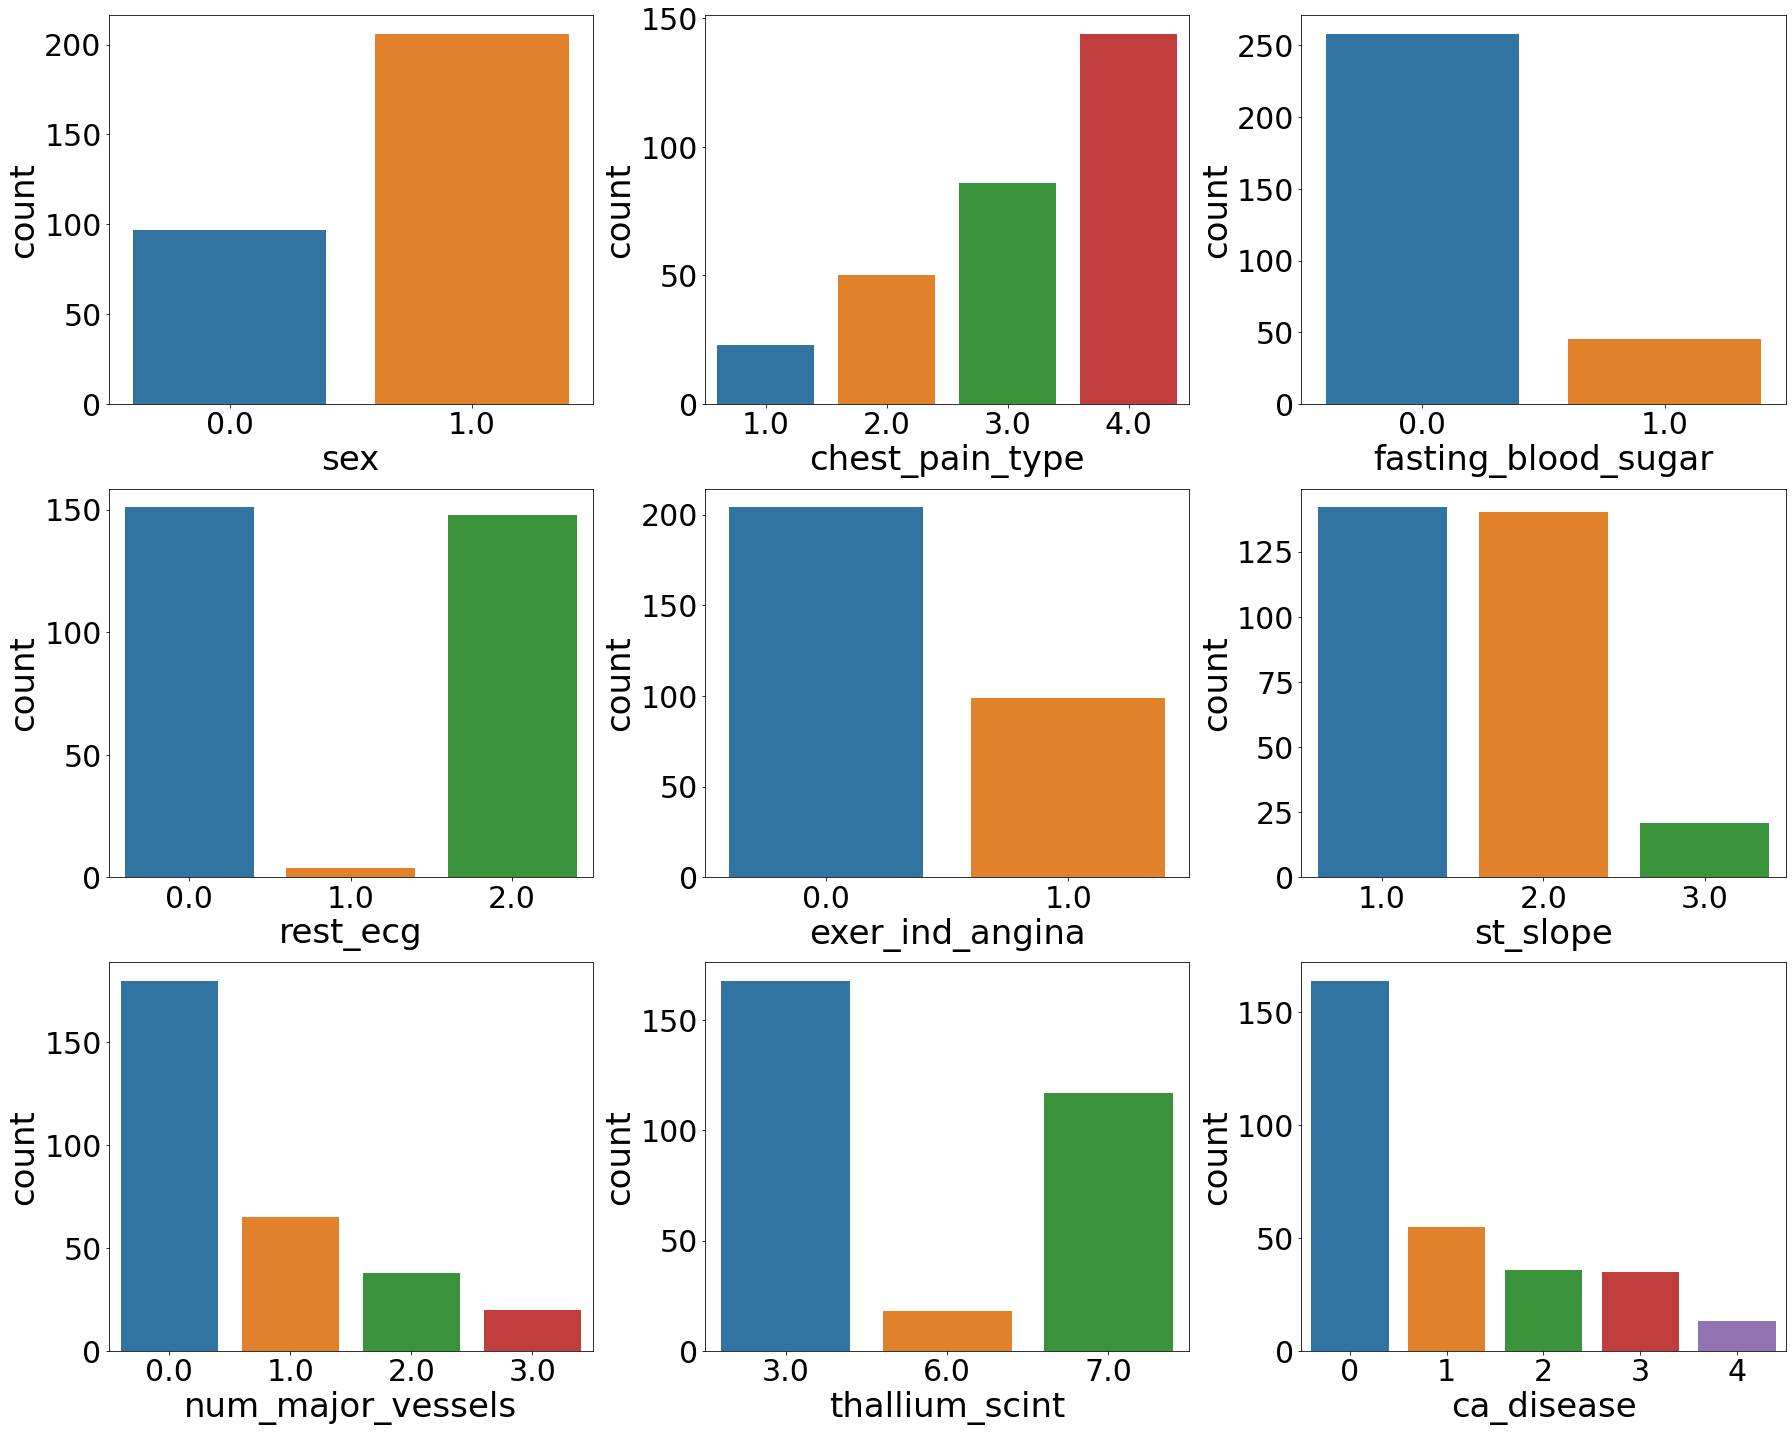

In [13]:
# Bar chart plot of categorical variables.
fig, ax = plt.subplots(3, 3, figsize=(25, 20));
for variable, subplot in zip(names_cat, ax.flatten()):
    subplot.xaxis.label.set_size(34)
    subplot.yaxis.label.set_size(34)
    subplot.tick_params('y', labelsize = 30);
    subplot.tick_params('x', labelsize = 30);
    cp = sns.countplot(x=df_fin_cat[variable], ax=subplot);
plt.tight_layout()

The data looks fine from a modelling perspective, apart from the fact that the 'thallium_scint' variable needs to be recoded.
The values are not coded in the correct order.

Next, let us consider the continuous variables.

We start by looking at age patterns.

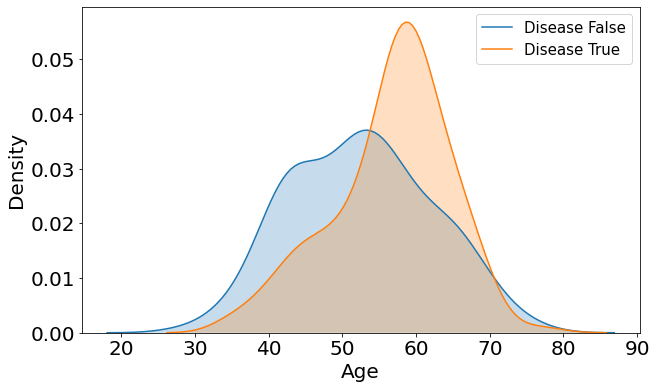

In [14]:
# Continuous density plot
df_fin_num['ca_disease'] = df_fin_num['ca_disease'].apply(lambda x: 1 if x > 0 else 0)

fig_age, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), squeeze=False)
_ = plotAge(df=df_fin_num, axes=axes, single_plot=True);

It is clear that individuals suffering from coronary artery disease have a higher average age.

In [15]:
# 5 number summary.
df_fin_con.describe()

,age,rest_blood_press,cholesterol,max_heart_rate,st_depression
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


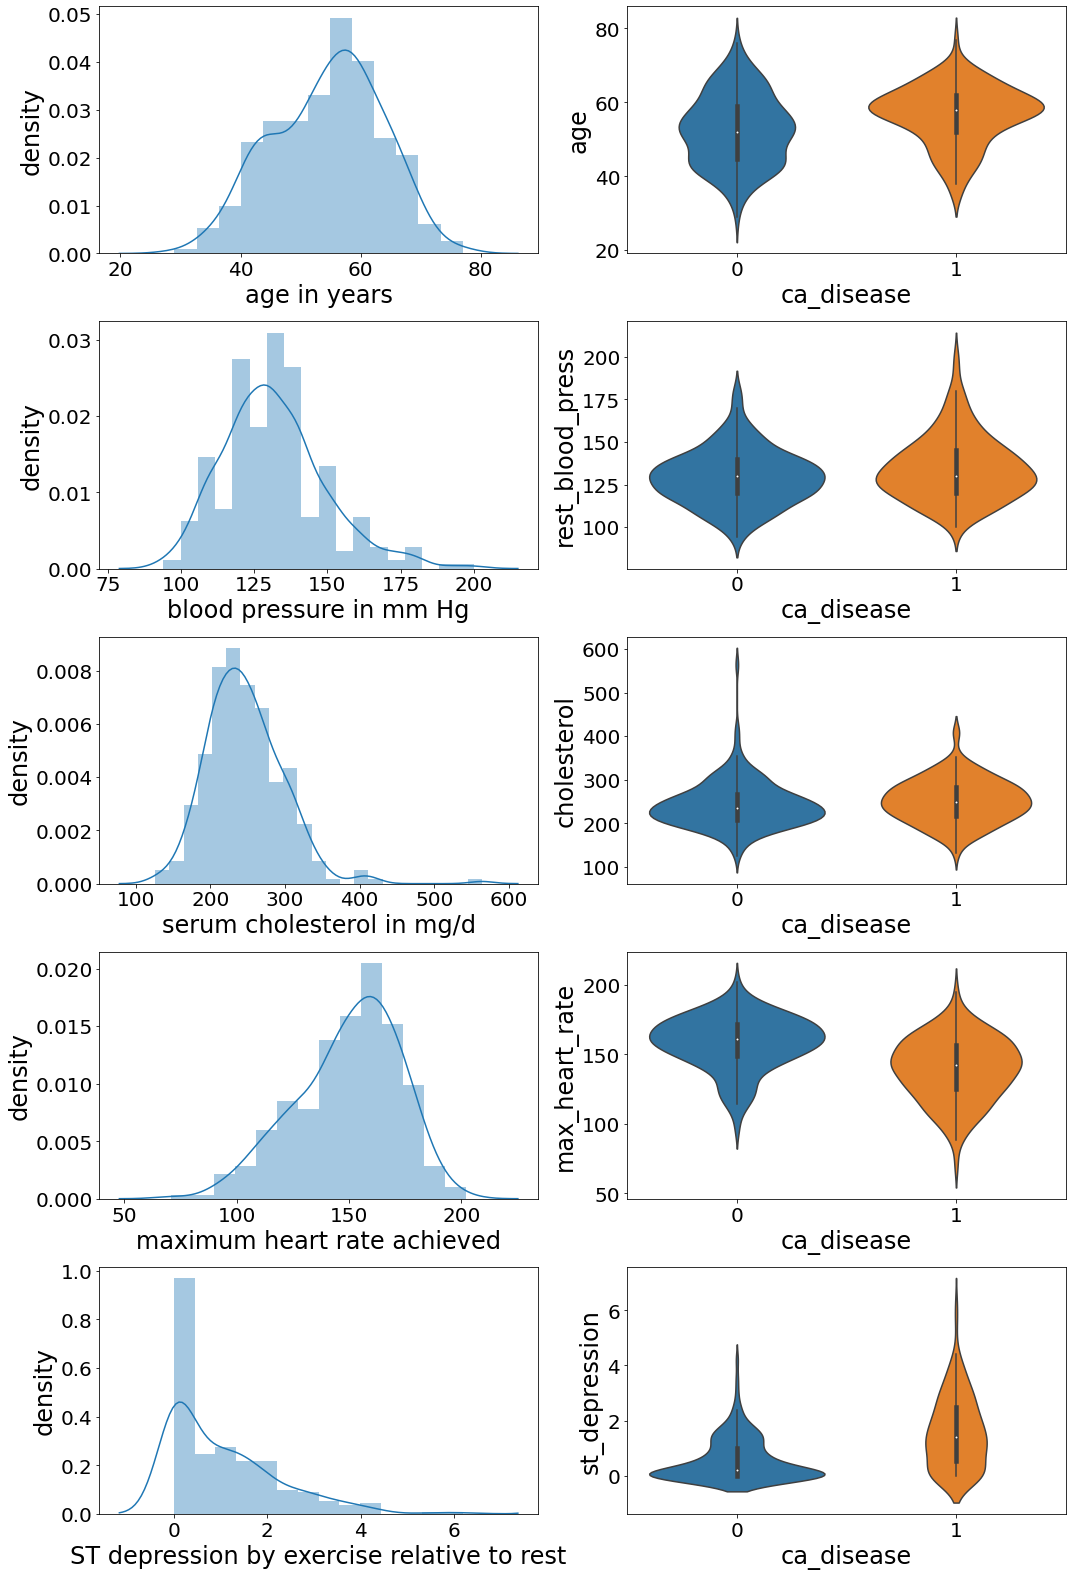

In [16]:
# Continuous density plot
#df_fin_num['ca_disease'] = df_fin_num['ca_disease'].apply(lambda x: 1 if x > 0 else 0)

fig_continuous, axes = plt.subplots(nrows=len(plot_con)-1, ncols=2, figsize=(15, 22))
_ = plotVar(isCategorical=False, categorical = plot_cat, continuous = plot_con, df=df_fin_num, axes=axes);

The violin plots demonstrate that the distributions for age, maximum HR and ST depression differ between individuals
with and those without ca disease, whereas there is little difference in the distributions for resting BP and
cholesterol.

The violin plot for age against coronary artery disease demonstrates that the age of individuals without ca disease is
evenly spread between the ages of 40 and 65, with some younger patients below the age of 30, whereas individuals with
ca disease are mostly older, with a median age of approx 60 and few, if any, below 30 years of age.

The median maximum HR for individuals without ca disease is higher (\~160) than for individuals with ca disease (\~150),
with a narrower distribution around the mean, whereas individuals with ca disease have a skewed distribution towards
lower maximum HR, with a larger proportion having max HR below 100 than healthy individuals.

The distribution for ST depression is starkly different, with individuals without ca disease having a median ST
depression of 0, with a narrow distribution around the mean, and a small proportion having ST depression between 1 and 2.

In contrast, individuals with ca disease follow a broader distribution around a median of ~1.5, with a substantial
proportion of individuals with ST depression >2. Resting blood pressure and cholesterol do not appear to be
significantly different between patients with and without ca disease, with both groups having similar median resting
BP (around 125mmHg) and cholesterol (200-250) and roughly even spread around the point estimates. A small number of
individuals with ca disease have much higher resting BP of >200, whereas none of those without ca disease have a
resting BP >200. However, this may not be statistically significant. Interestingly, some individuals without ca disease
have very high cholesterol (500-600).

In [17]:
for variable in names_con:
    skew = df_fin_con[variable].skew()
    print("Skewness value for {}: {}".format(variable, skew))

Skewness value for age: -0.20906046882012877
Skewness value for rest_blood_press: 0.7060346498131783
Skewness value for cholesterol: 1.1355031533363453
Skewness value for max_heart_rate: -0.5374486699106463
Skewness value for st_depression: 1.2697199306019966


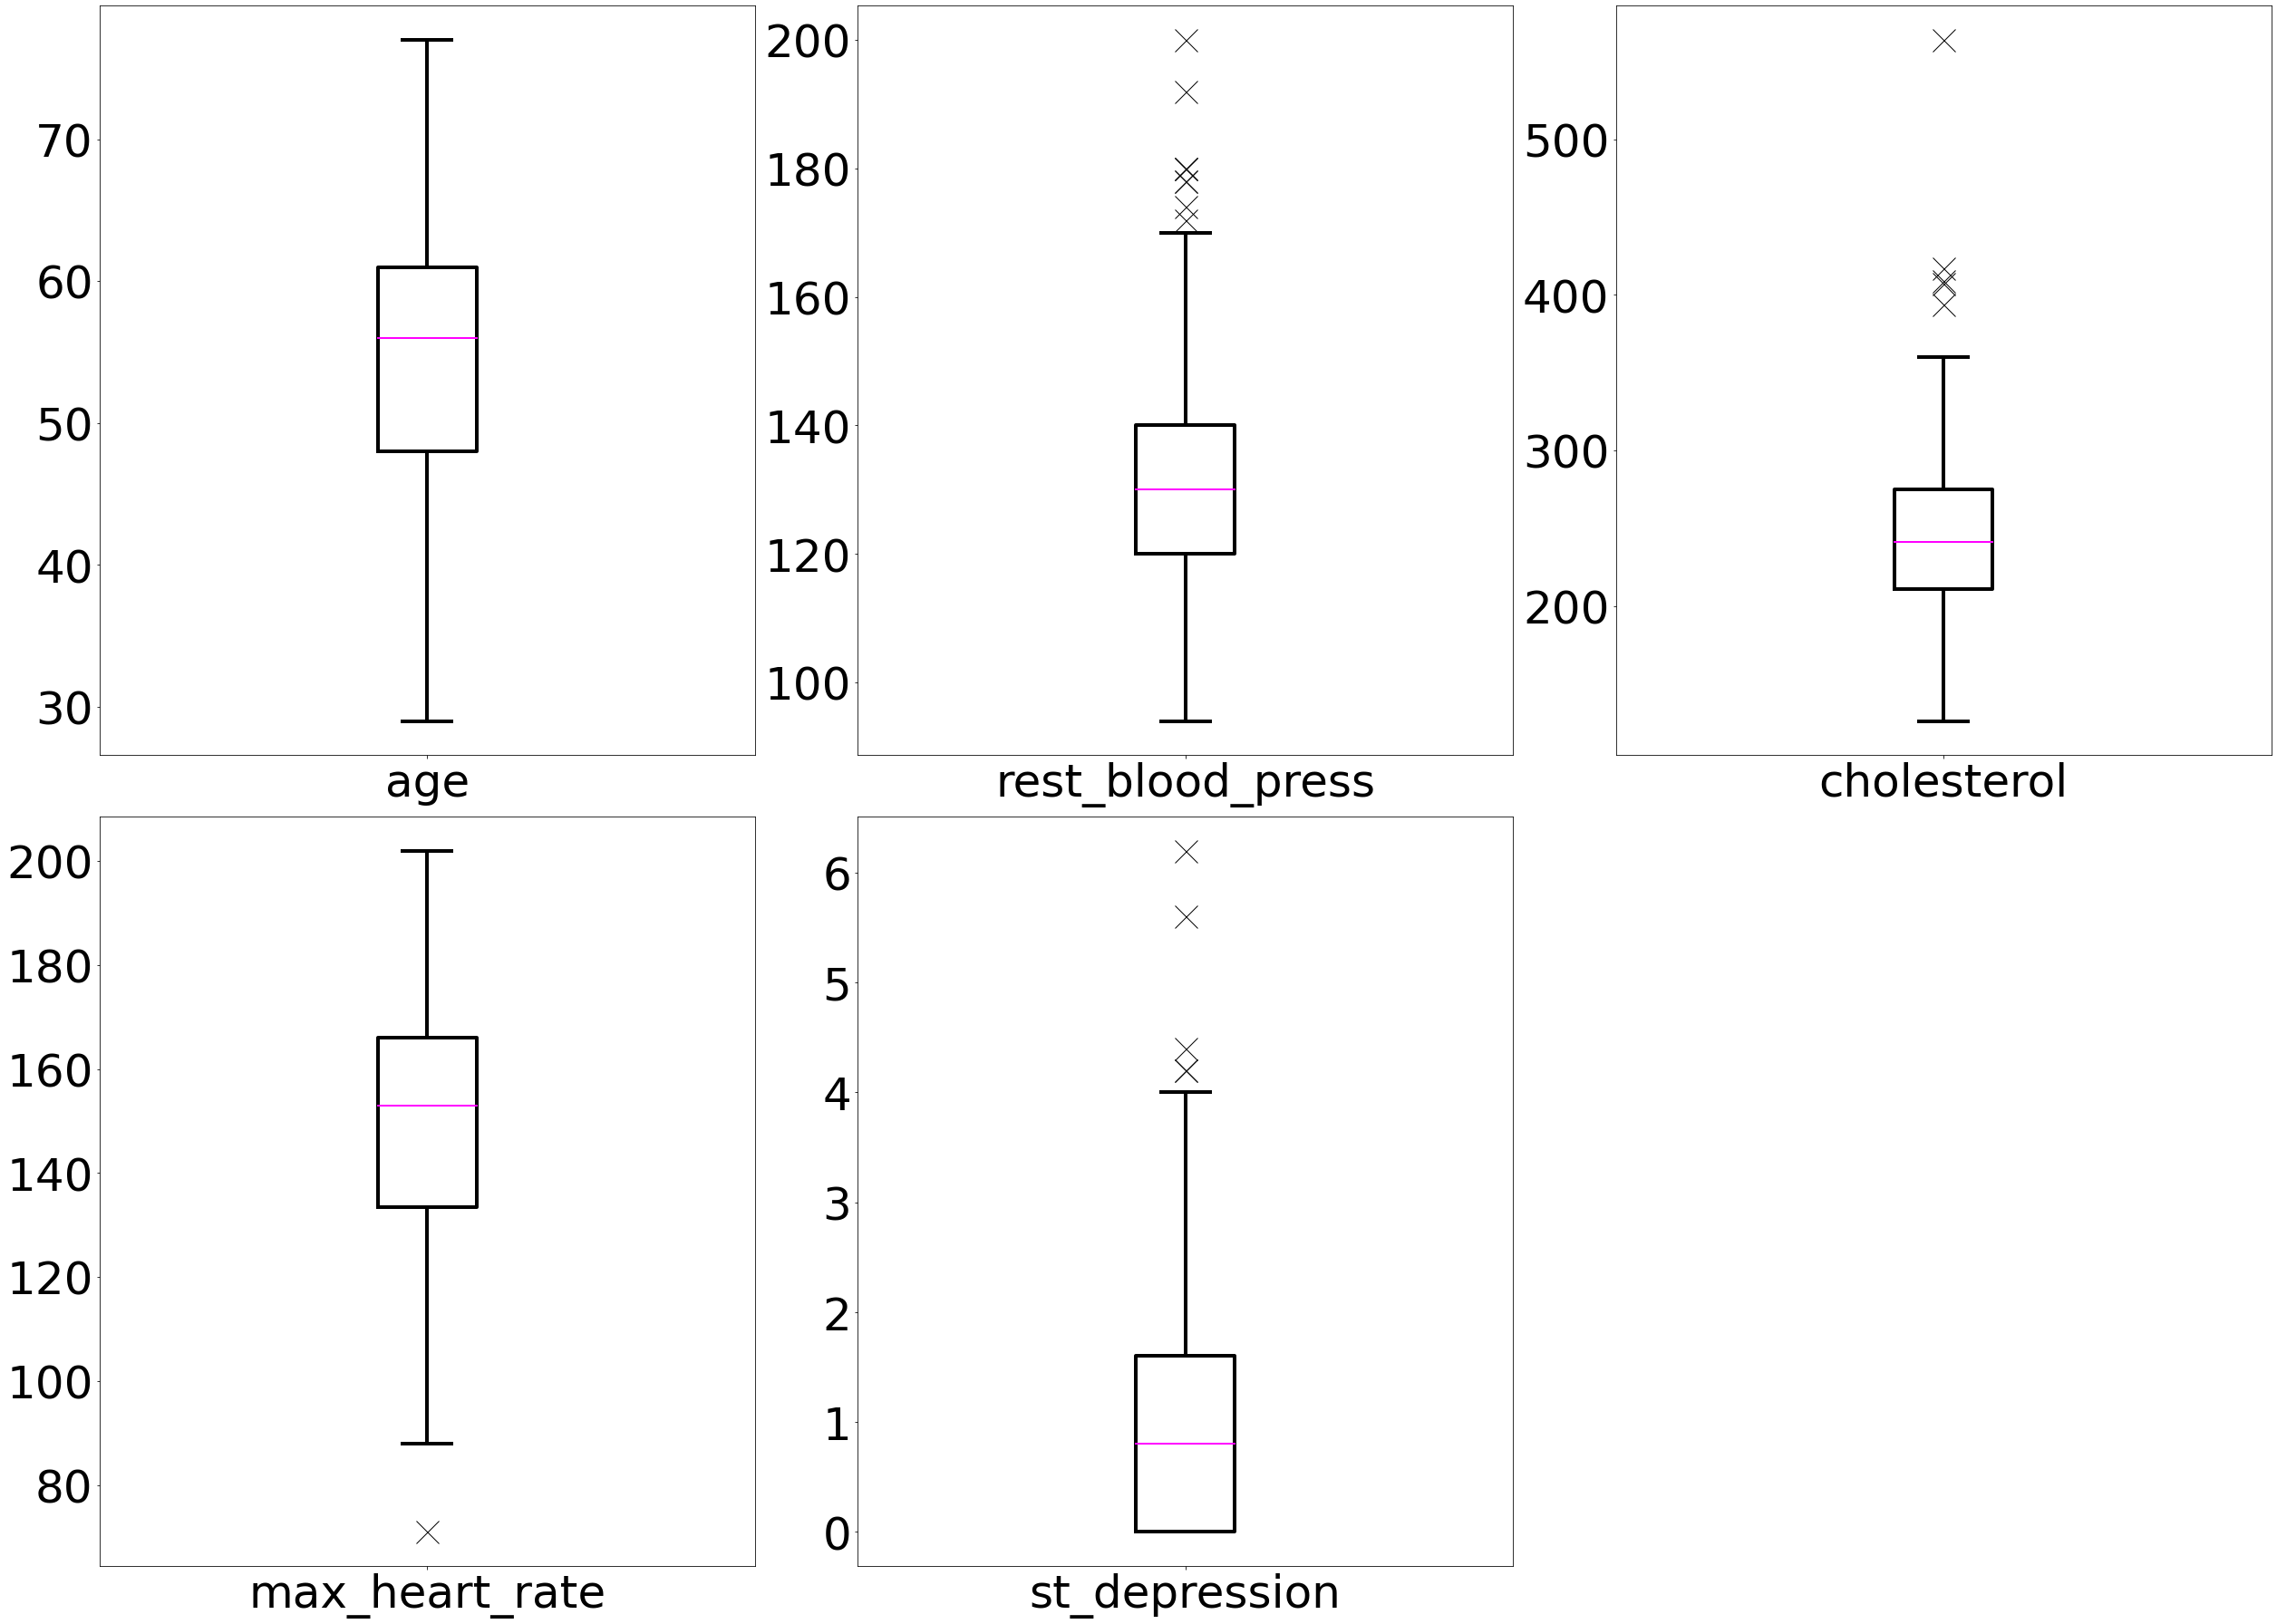

In [18]:
# Boxplot of continuous variables
medianprops = {'color': 'magenta', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-', 'linewidth': 4}
whiskerprops = {'color': 'black', 'linestyle': '-', 'linewidth': 4}
capprops = {'color': 'black', 'linestyle': '-', 'linewidth': 4}
flierprops = {'color': 'black', 'marker': 'x', 'markersize': 25}

_ = df_fin_con.plot(kind='box', subplots=True, figsize=(35, 25), layout=(2,3), fontsize = 50, medianprops=medianprops,
                    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops=flierprops);

_ = plt.tight_layout();
_ = plt.show();

No surprises here with regards to the continuous feature variables, similar observations to those made for the density
and violin plots. We are dealing with an older population here with average age of 54 years old. There are a few
outliers for high resting blood pressure with the distribution showing a slight skew to the right. Likewise for
cholesterol and st_depression, with these two showing even higher skewness. Conversely max_heart_rate has outliers
to left and slight skewness to left too. This makes sense, as higher values for the prior could indicate poorer
health, whereas lower values for max_heart_rate could indicate poorer health, as observed in the violin plots.

The distributions of the feature variables have varying scales, so standardisation would be required for ML purposes.
For regression, normalisation might improve outcomes (for this investigation we will however not perform normalisatoin).
Investigation into outliers is recommended as it might reveal interesting facts and would improve the model performance
if outliers were addressed.

<div class="alert alert-block alert-info">
<b>Build Naive Model - Baseline</b>
</div>

We start by splitting the response and the features.

In [19]:
# Transform y variable
df_fin['ca_disease'] = df_fin['ca_disease'].apply(lambda x: 1 if x > 0 else 0)

# Copy original dataset
df_fin_nn = df_fin.copy()

# Group response values to form binary response
y = df_fin_nn.loc[:, 'ca_disease']

# Split data into features (X) and response (y)
X = df_fin_nn.loc[:, ('age', 'sex', 'chest_pain_type', 'rest_blood_press', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exer_ind_angina', 'st_depression', 'st_slope',
                   'num_major_vessels', 'thallium_scint')]

X.head()

# Put the response y into an array
y = np.ravel(y)

,age,sex,chest_pain_type,rest_blood_press,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exer_ind_angina,st_depression,st_slope,num_major_vessels,thallium_scint
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


Split the data into training and test sets

In [20]:
X_train_init, X_test_init, y_train_init, y_test_init = train_test_split(X, y, random_state=0)

In [21]:
print('Percentage holdout data: {}%'.format(round(100*(len(X_test_init)/len(X)),0)))

Percentage holdout data: 25.0%


We now build and test a naive logistic regression model - without any transformations or optimisations.

AUC: 0.8673611111111111


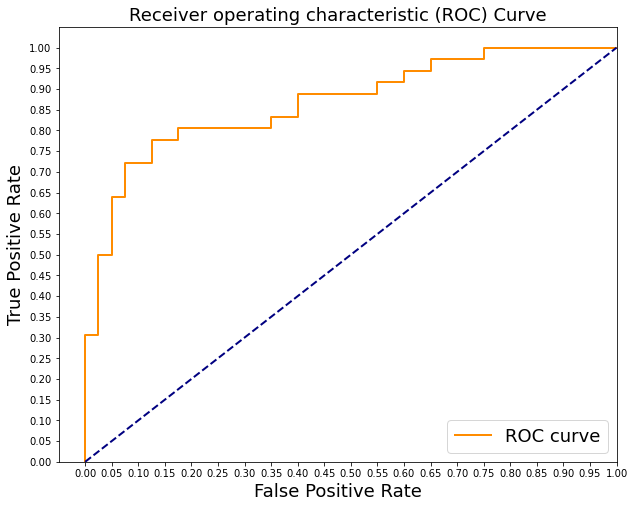

In [22]:
# Initial model
logreg = LogisticRegression(max_iter=2000000, fit_intercept = False)

# Probability scores for test set
y_score_init = logreg.fit(X_train_init, y_train_init).decision_function(X_test_init)

# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_init, y_score_init)

plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.825  
precision:			0.799 
sensitivity:			0.867

specificity:			0.783 
negative predictive value:	0.854

false positive rate:		0.217  
false negative rate:		0.133 
false discovery rate:		0.201


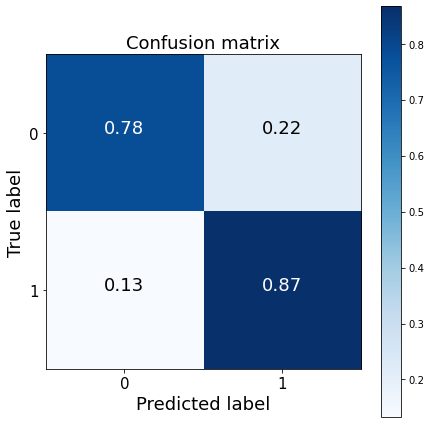

In [23]:
y_pred = logreg.predict(X_test_init)
# Accuracy before model parameter optimisation
cnf_matrix = confusion_matrix(y_pred, y_test_init)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

<div class="alert alert-block alert-info">
<b>Build Logistic Regression - Release 1</b>
</div>

Scale and transform variables

In [24]:
# Transform thallium_scint variable
trans_thal = {3:0, 7:1, 6:2}
df_fin_nn = df_fin.replace({"thallium_scint": trans_thal})
feature_names = ('age', 'sex', 'chest_pain_type', 'rest_blood_press', 'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
                 'max_heart_rate', 'exer_ind_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thallium_scint')

# Re-extract transformed X features
X = df_fin_nn.loc[:, feature_names]


# Rebuild training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Create variables for Random Forest model
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

# Scale data
scaler = StandardScaler()

# Fit on training data set
scaler.fit(X_train)
X_train = scaler.transform(X_train)

# Apply to test data
X_test = scaler.transform(X_test)

StandardScaler()

We now build a logistic regression model with data scaled and transformed according to Exploratory Data Analysis
results num_major_vessels and exer_ind_angina also have very small confidence intervals and high accuracy scores.

AUC: 0.8770833333333333


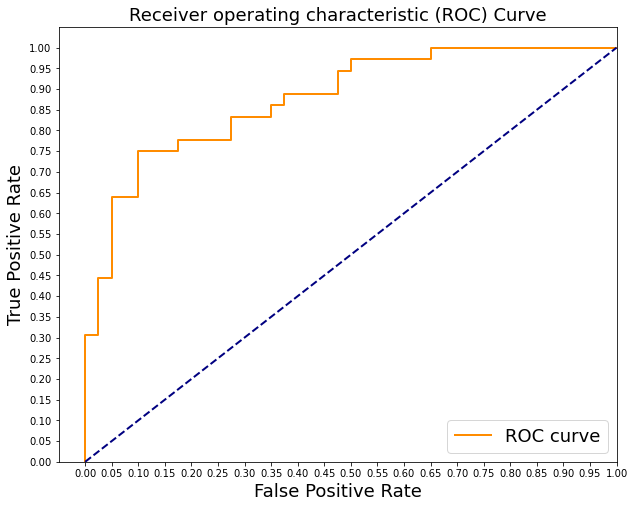

In [25]:
# Initial model
logreg = LogisticRegression(fit_intercept = False)

# Probability scores for test set
y_score = logreg.fit(X_train, y_train).decision_function(X_test)

# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test, y_score)

plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.82  
precision:			0.805 
sensitivity:			0.844

specificity:			0.795 
negative predictive value:	0.836

false positive rate:		0.205  
false negative rate:		0.156 
false discovery rate:		0.195


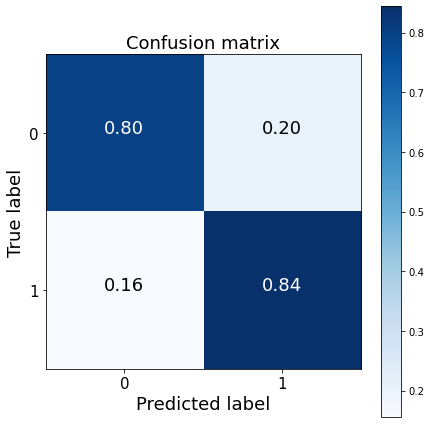

In [26]:
y_pred = logreg.predict(X_test)
# Accuracy before model parameter optimisation
cnf_matrix = confusion_matrix(y_pred, y_test)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

We observe a modest improvement in accuracy for the model with the data minimally transformed and scaled.
Although accuracy in itself probably does not warrant the transformation and scaling, model performance in terms of
convergence has improved by an order of magnitude as number of iterations required before convergence was previously
larger than 1000,000 and after the data has been scaled number of iterations reduced to less than 100 0000.

<div class="alert alert-block alert-info">
<b>Build Logistic Regression - Release 2</b>
</div>

We now perform feature selection in order to ascertain whether a smaller parsimonious model could be built with fewer
variables. As per the article by (Detrano et al., 1989) this could be useful from a practical perspective as not all
healthcare settings have all the variables to their disposal which necessitates the deployment of several complex
predictive models which is not practical from an operational perspective.

We will first perform correlation and regression tests on the data. These tests are best performed by considering
continuous and categoric variables separately due to the intrinsic difference in regression coefficient values
for these variables. We will then perform a few numeric methods on the full dataset and compare results.

We start by considering the continuous variables.

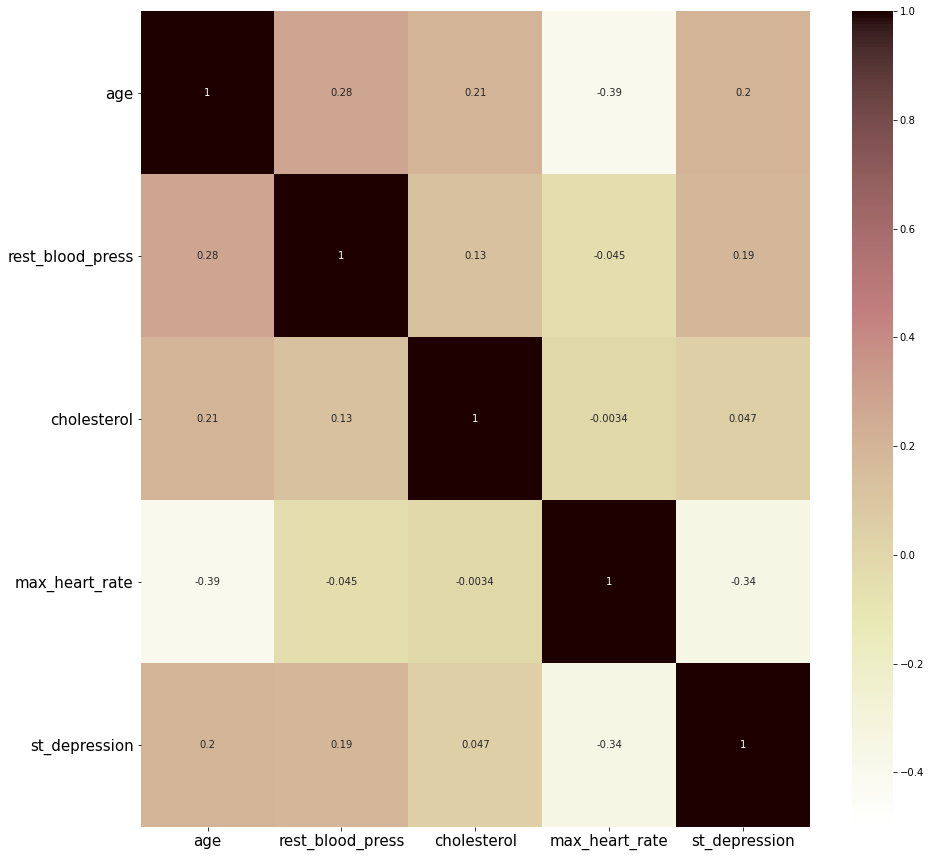

In [27]:
# Pearson correlation plot.
correlations = df_fin_con.corr()
# Plot correlation matrix
#sns.set(font_scale=1);
fig = plt.figure(figsize=(15, 15))
ax = sns.heatmap(correlations, annot=True, linewidths = 0, vmin=-.5, cmap='pink_r')
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
#ax.title.set_size(45)
ax.tick_params('y', labelsize = 15, labelrotation=0);
ax.tick_params('x', labelsize = 15);

We see that there is a very strong inverse correlation between maximum heart rate and age. This makes sense as one's
maximum heart typically decreases with age. We also see that there is a strong positive correlation between maximum
heart rate and both cholesterol and resting blood pressure. This too makes sense as high blood pressure and cholesterol
are typically indications poor health which would result in lower maximum heart rate.
Another observation of interest is the strong correlation between cholesterol and the depression induced by exercise in
the ECG during exercise. These variables could make strong combined predictors for a next iteration of the model.
For now we will continue with the variables as is and focus on feature selection.

The first method we use is to compare the relative importance of logistic regression coefficient values for all our
continuous variables. Scikit-learn does not implement feature importance measures for logistic regression. We
therefore make use of the statsmodel libraries' implementation.

Optimization terminated successfully.
         Current function value: 0.509602
         Iterations 6
                         Results: Logit
Model:              Logit            Pseudo R-squared: 0.260     
Dependent Variable: y                AIC:              241.3593  
Date:               2024-01-24 18:40 BIC:              258.4841  
No. Observations:   227              Log-Likelihood:   -115.68   
Df Model:           4                LL-Null:          -156.37   
Df Residuals:       222              LLR p-value:      8.8664e-17
Converged:          1.0000           Scale:            1.0000    
No. Iterations:     6.0000                                       
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
age                0.0147   0.0176  0.8334 0.4046 -0.0199  0.0493
rest_blood_press   0.0160   0.0097  1.6516 0.0986 -0.0030  0.0349


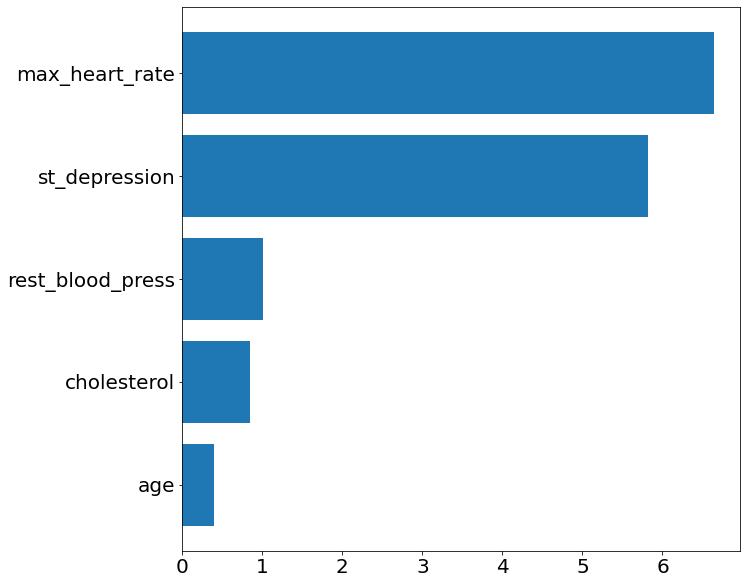

In [28]:
# Extract continuous and categorical variables for analysis.
X_con = df_fin_con.copy()
X_cat = df_fin_cat.loc[:,('sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exer_ind_angina', 'st_slope', 'num_major_vessels', 'thallium_scint')]

X_train_con, X_test_con, y_train_con, y_test_con = train_test_split(X_con, y, random_state=0)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y, random_state=0)

log_reg = sm.Logit(y_train_con, X_train_con)
log_result = log_reg.fit()

print(log_result.summary2())
features_con = np.array(names_con)
plot_feature_importance_log(fit = log_result, features = features_con)

From this analysis it can be seen that the only variables of significance are max_heart_rate and st_depression.
The remainder of the variables will be rejected based on their coefficient sizes.

Now we perform a univariate comparison between all the features. We use the mlxtend library for this. We fit a
Logistic regression model to each variable in turn and study the accuracy obtained.

Features: 13/13

Best accuracy score: 0.77
Best subset (indices): (12,)
Best subset (corresponding names): ('thallium_scint',)


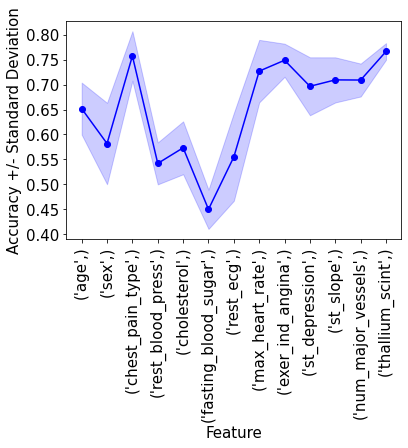

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
12,"(12,)","[0.7391304347826086, 0.782608695652174, 0.7555...",0.76657,"(thallium_scint,)",0.0213739,0.0166296,0.00831479
2,"(2,)","[0.782608695652174, 0.782608695652174, 0.82222...",0.757488,"(chest_pain_type,)",0.0637724,0.0496171,0.0248085
8,"(8,)","[0.7391304347826086, 0.7608695652173914, 0.777...",0.748889,"(exer_ind_angina,)",0.0426589,0.0331901,0.016595
7,"(7,)","[0.6739130434782609, 0.7391304347826086, 0.844...",0.727053,"(max_heart_rate,)",0.0806021,0.0627112,0.0313556
10,"(10,)","[0.6304347826086957, 0.7391304347826086, 0.733...",0.709469,"(st_slope,)",0.0581748,0.045262,0.022631
11,"(11,)","[0.6956521739130435, 0.7391304347826086, 0.666...",0.709179,"(num_major_vessels,)",0.0424334,0.0330146,0.0165073
9,"(9,)","[0.6304347826086957, 0.6304347826086957, 0.711...",0.696618,"(st_depression,)",0.0747359,0.0581471,0.0290735
0,"(0,)","[0.6304347826086957, 0.717391304347826, 0.6, 0...",0.651787,"(age,)",0.0671384,0.052236,0.026118
1,"(1,)","[0.5434782608695652, 0.5652173913043478, 0.577...",0.581739,"(sex,)",0.104977,0.0816756,0.0408378
4,"(4,)","[0.5217391304347826, 0.5217391304347826, 0.577...",0.57314,"(cholesterol,)",0.0681916,0.0530554,0.0265277


In [29]:
logval = LogisticRegression(fit_intercept = False)

efs1 = EFS(logval,
           min_features=1,
           max_features=1,
           scoring='accuracy',
           print_progress=True,
           cv=5)

efs1 = efs1.fit(X_train, y_train, custom_feature_names=feature_names)

print('Best accuracy score: %.2f' % efs1.best_score_)
print('Best subset (indices):', efs1.best_idx_)
print('Best subset (corresponding names):', efs1.best_feature_names_)

#efs1 = efs1.fit(X, y, custom_feature_names=feature_names)

df_efs = pd.DataFrame.from_dict(efs1.get_metric_dict()).T
df_efs.sort_values('avg_score', inplace=True, ascending=False)

metric_dict = efs1.get_metric_dict()

fig = plt.figure()
k_feat = sorted(metric_dict.keys())
avg = [metric_dict[k]['avg_score'] for k in k_feat]

upper, lower = [], []
for k in k_feat:
    upper.append(metric_dict[k]['avg_score'] +
                 metric_dict[k]['std_dev'])
    lower.append(metric_dict[k]['avg_score'] -
                 metric_dict[k]['std_dev'])

plt.fill_between(k_feat,
                 upper,
                 lower,
                 alpha=0.2,
                 color='blue',
                 lw=1)

_ = plt.plot(k_feat, avg, color='blue', marker='o');
_ = plt.ylabel('Accuracy +/- Standard Deviation', size = 15)
_ = plt.xlabel('Feature', size = 15)
feature_min = len(metric_dict[k_feat[0]]['feature_idx'])
feature_max = len(metric_dict[k_feat[-1]]['feature_idx'])
_ = plt.xticks(k_feat,
           [str(metric_dict[k]['feature_names']) for k in k_feat],
           rotation=90, size = 15)
_ = plt.yticks(size = 15)
plt.show();

df_efs

From this analysis we can see that there are a large number of very strong predictors in this set of variables.
thallium_scint scores 77% for accuracy and has the smallest confidence interval. exer_ind_angina and num_major_vessels
similarly have high accuracy and small confidence intervals. chest_pain_type and max_heart_rate also have very high
accuracy scores.

Next we will however make use of scikit-learn's native feature extraction methods - which also allow for Univariate
tests. The Uni-variate Anova test on continuous variables as implemented in SelectKBest function 'f_classif' will
be used. Let's see what the results are.

Feature:       max_heart_rate	Score:	11.81243
Feature:        st_depression	Score:	11.80165
Feature:                  age	Score:	3.80501
Feature:     rest_blood_press	Score:	1.77980
Feature:          cholesterol	Score:	1.20672


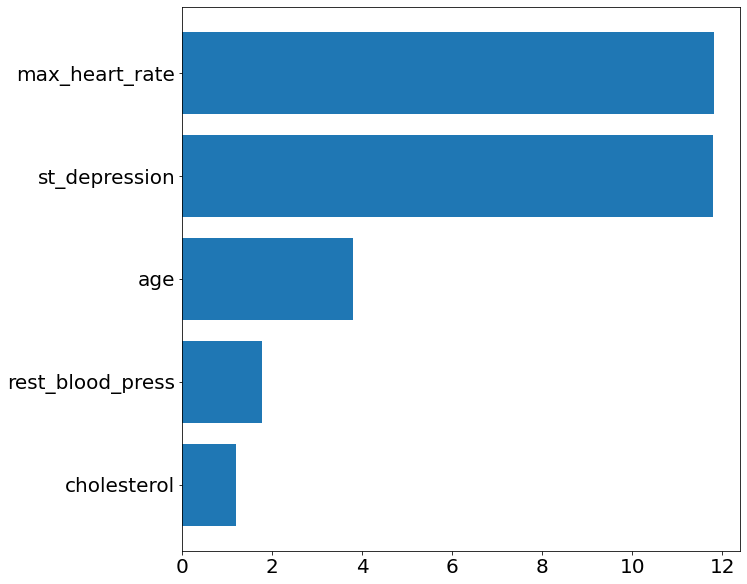

In [30]:
# Feature extraction set to retain all - we want to see scores for all variables.
test = SelectKBest(score_func=f_classif, k=5)
fit_kbest = test.fit(X_train_con, y_train_con)
features_kbest = np.array(X_con.columns)
plot_feature_importance(fit = fit_kbest, features = features_kbest)

What is notable in this analysis is the fact that age shows a higher significance here than for the previous test.
This is due to the fact that age and max_heart_rate are cross-correlated as seen from Pearson's cross correlation test -
reported a bit later in this document. The strong correlation between max_heart_rate and ca_disease diminishes the
impact of age in multivariate tests. Univariate tests are better suited to this analysis for this reason.

Although age does clearly have some value as a variable, and in general it is good to include in any regression
analysis due to the insights it brings, we will exclude it based on test results and levels of significance of other
variables being much greater and capturing the effect of age sufficiently. We later discuss a strategy for the inclusion
of age at a later stage.

We will now consider the categorical variables. Again the SelectKBest method will be used again, but this time the
Chi-Squared function 'chi2' for categorical variables will be used. Let's see what the results are.

Feature:    num_major_vessels	Score:	13.64256
Feature:       thallium_scint	Score:	12.12447
Feature:      exer_ind_angina	Score:	9.16471
Feature:      chest_pain_type	Score:	3.09327
Feature:             st_slope	Score:	2.11834
Feature:                  sex	Score:	1.14705
Feature:             rest_ecg	Score:	0.87596
Feature:  fasting_blood_sugar	Score:	0.06877


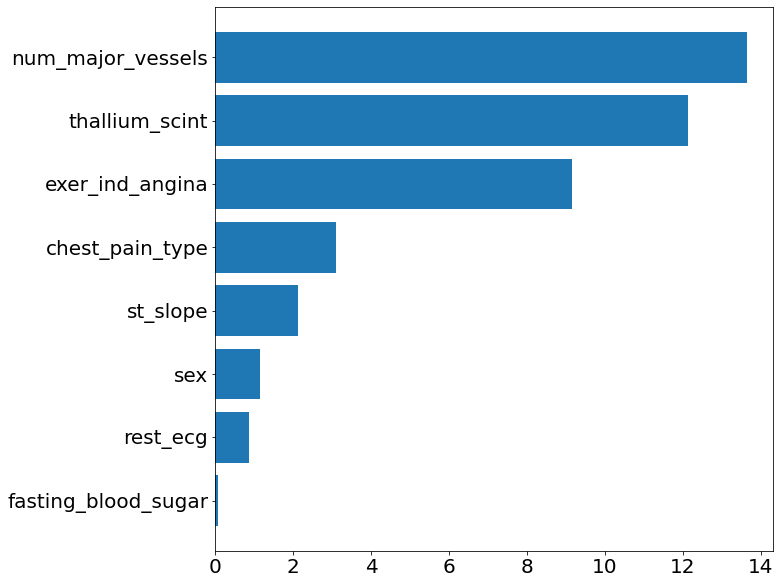

In [31]:
test_cat = SelectKBest(score_func=chi2, k='all')
fit_kbest_cat = test_cat.fit(X_train_cat, y_train_cat)
features_kbest_cat = np.array(X_cat.columns)
plot_feature_importance(fit = fit_kbest_cat, features = features_kbest_cat)

num_major_vessels, thal_scint and exer_ind_angina are all extremely strong predictors. chest_pain_type, st_slope and
sex also contribute to the overall classification. From this analysis the only non-significant variables are
rest_ecg and fasting_blood_sugar.

We have now analysed continuous at categorical data separately from a statistical perspective.
Before we make the final decision on what variables to drop, we will now consider an ML technique for deriving feature
importance i.e. Decision Trees and Random Forests. Unlike the case of regression, we can analyse and draw conclusions
on continuous and categorical data together when using these algorithms as they are impervious to differences in
variable type. Another nice feature about Trees is that we don't have to standardise and normalise features which
makes visual analysis a lot more intuitive. We therefore use our initial untransformed dataset for this analysis.

AUC: 0.6972222222222222


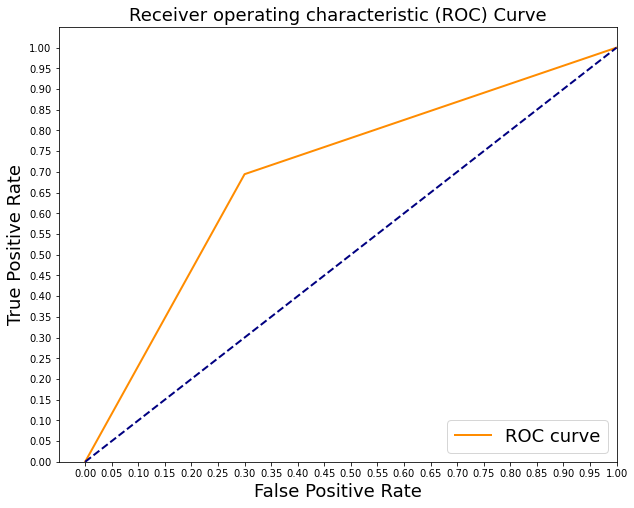

In [32]:
# Fit a Decision Tree to data - perform cross validation to obtain optimum value for hyperparameter used for pruning.
samples = [sample for sample in range(1,30)]
validation_scores = []
for sample in samples:
    classifier1 = DecisionTreeClassifier(random_state=1, min_samples_leaf=sample)
    score = cross_val_score(estimator=classifier1, X=X_train_rf, y=y_train_rf, cv=5)
    validation_scores.append(score.mean())

# Obtain the minimum leaf samples with the highest validation score
samples_optimum = samples[validation_scores.index(max(validation_scores))]

# Create final classifier
classifier2 = DecisionTreeClassifier(random_state=0, min_samples_leaf=samples_optimum)
classifier2 = classifier2.fit(X_train_rf, y_train_rf)

# Probability scores for test set
y_pred_rf = classifier2.predict(X_test_rf)

# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_rf, y_pred_rf)
plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.697  
precision:			0.705 
sensitivity:			0.676

specificity:			0.718 
negative predictive value:	0.689

false positive rate:		0.282  
false negative rate:		0.324 
false discovery rate:		0.295


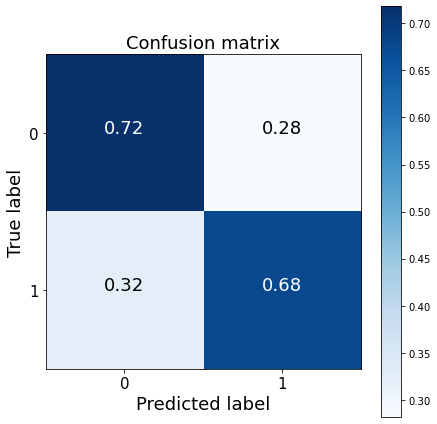

In [33]:
cnf_matrix = confusion_matrix(y_pred_rf, y_test_rf)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

Feature:       thallium_scint	Score:	0.52965
Feature:      exer_ind_angina	Score:	0.13927
Feature:        st_depression	Score:	0.12318
Feature:                  age	Score:	0.09639
Feature:      chest_pain_type	Score:	0.06617
Feature:          cholesterol	Score:	0.04124
Feature:    num_major_vessels	Score:	0.00410
Feature:             st_slope	Score:	0.00000
Feature:       max_heart_rate	Score:	0.00000
Feature:             rest_ecg	Score:	0.00000
Feature:  fasting_blood_sugar	Score:	0.00000
Feature:     rest_blood_press	Score:	0.00000
Feature:                  sex	Score:	0.00000


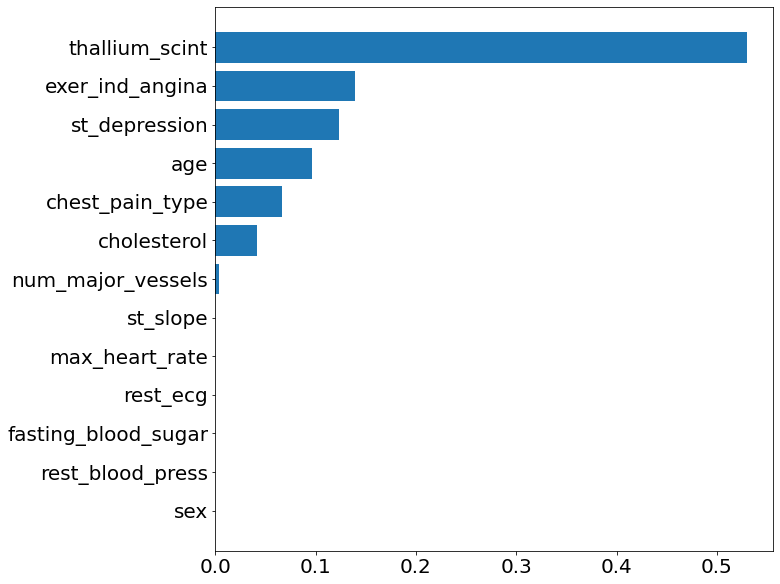

In [34]:
importances = np.array(classifier2.feature_importances_)
feature_list = np.array(X.columns)
plot_feature_importance_dec(fit = importances, features = feature_list)

In [35]:
# Show the first few levels of the tree
_ = export_graphviz(classifier2, out_file='tree.dot',
                feature_names = X.columns,
                class_names = ['No CAD', 'CAD'],
                rounded = True, proportion = True,
                label='root',
                precision = 2, filled = True);

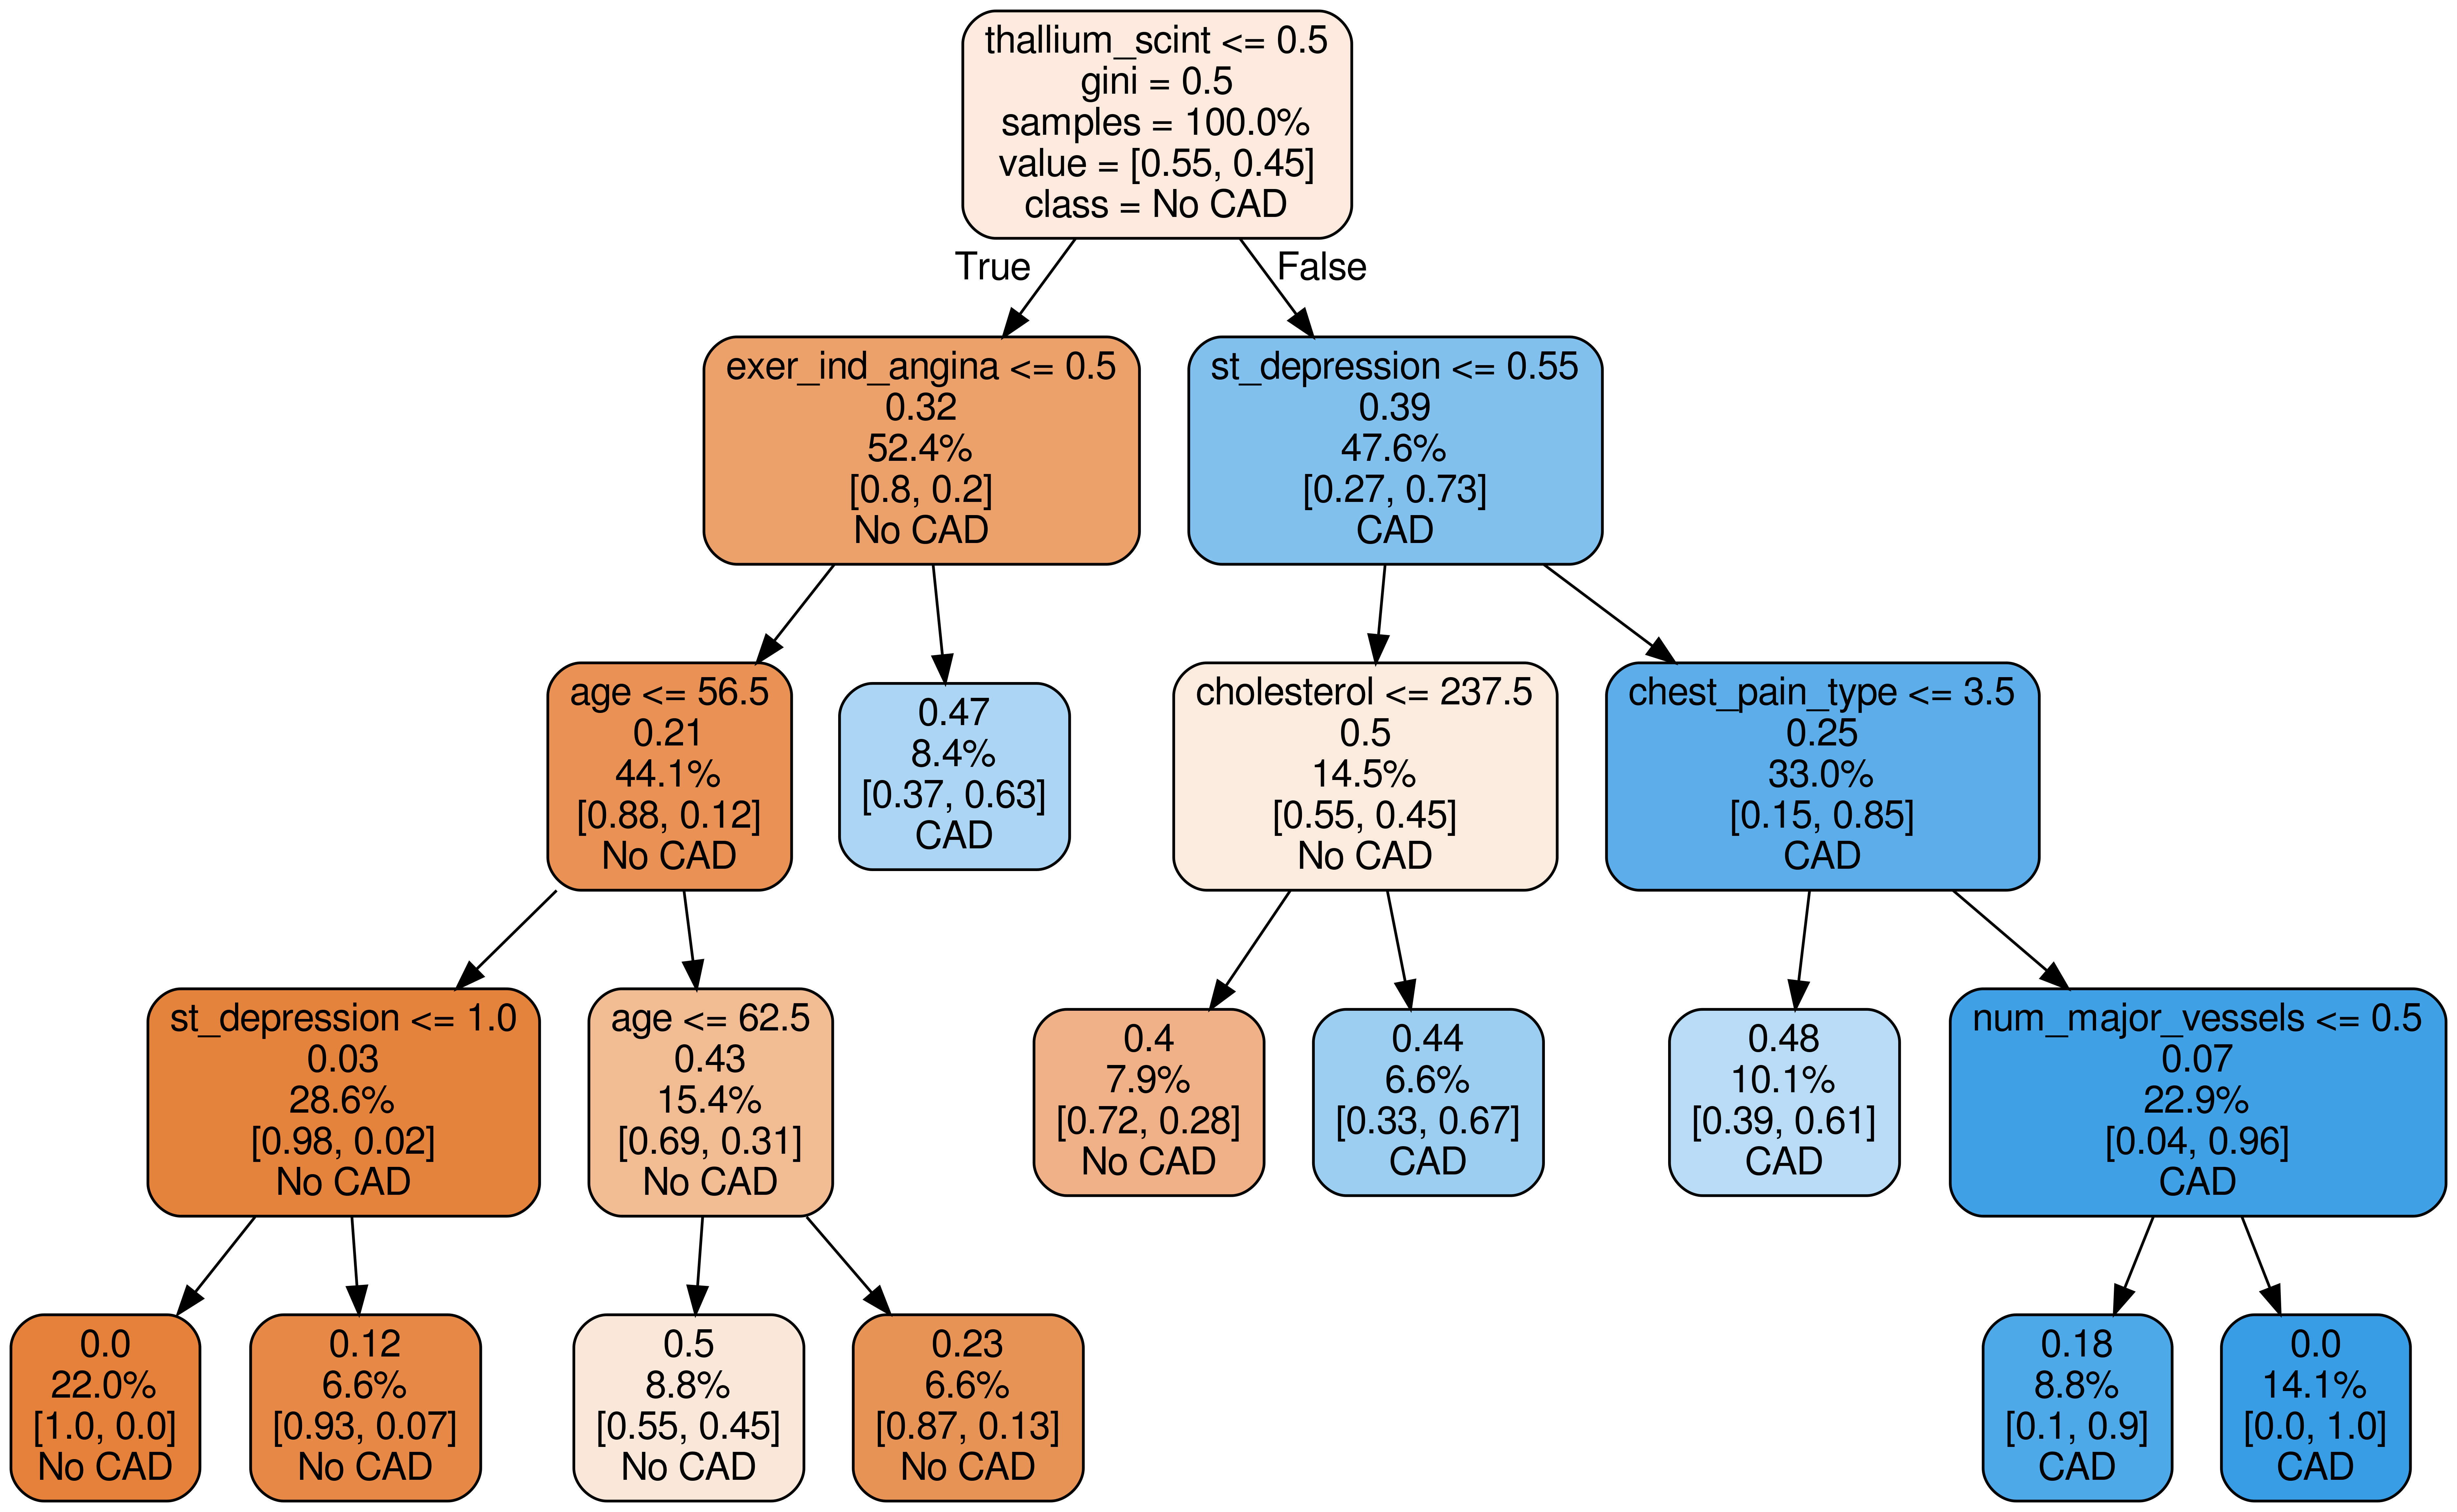

In [36]:
_ = call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])
Image(filename = 'tree.png')

The model has accuracy below 70% (ROC curve slope flatter than models thus far) and the feature importance results
are not very convincing seeing as many values are missing. This model needs a bit more work. Interesting to note
that Thallium Scintograpy comes out very strongly even in this sub-optimal model.
We will next look at random forests to see if we can improve on the single tree's accuracy.

RandomForestClassifier(max_features=0.25, n_estimators=1000, random_state=0)

AUC: 0.7708333333333333


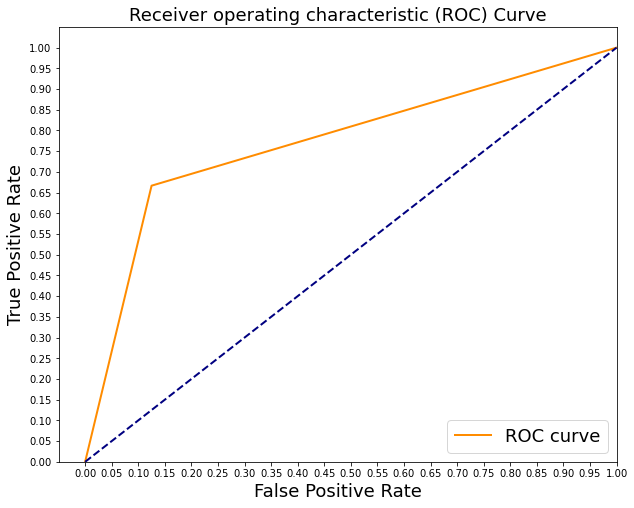

In [37]:
rand_forest = RandomForestClassifier(max_features=0.25, n_estimators=1000, criterion= 'gini',
                                     random_state=0)
rand_forest.fit(X_train_rf, y_train_rf)

# Probability scores for test set
y_pred_rf = rand_forest.predict(X_test_rf)

# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_rf, y_pred_rf)
plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.786  
precision:			0.764 
sensitivity:			0.828

specificity:			0.745 
negative predictive value:	0.812

false positive rate:		0.255  
false negative rate:		0.172 
false discovery rate:		0.236


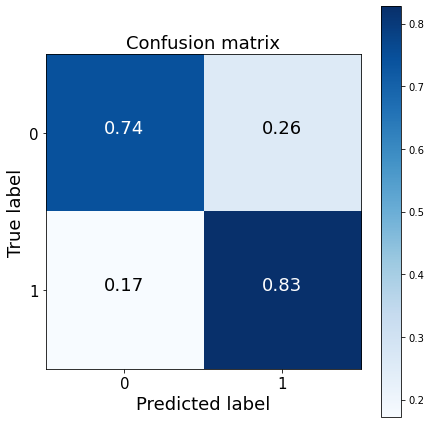

In [38]:
cnf_matrix = confusion_matrix(y_pred_rf, y_test_rf)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

Feature:       max_heart_rate	Score:	0.12651
Feature:       thallium_scint	Score:	0.12493
Feature:        st_depression	Score:	0.11981
Feature:      chest_pain_type	Score:	0.11469
Feature:                  age	Score:	0.09253
Feature:      exer_ind_angina	Score:	0.09140
Feature:          cholesterol	Score:	0.07834
Feature:     rest_blood_press	Score:	0.07699
Feature:    num_major_vessels	Score:	0.07549
Feature:             st_slope	Score:	0.05451
Feature:                  sex	Score:	0.01734
Feature:             rest_ecg	Score:	0.01635
Feature:  fasting_blood_sugar	Score:	0.01110


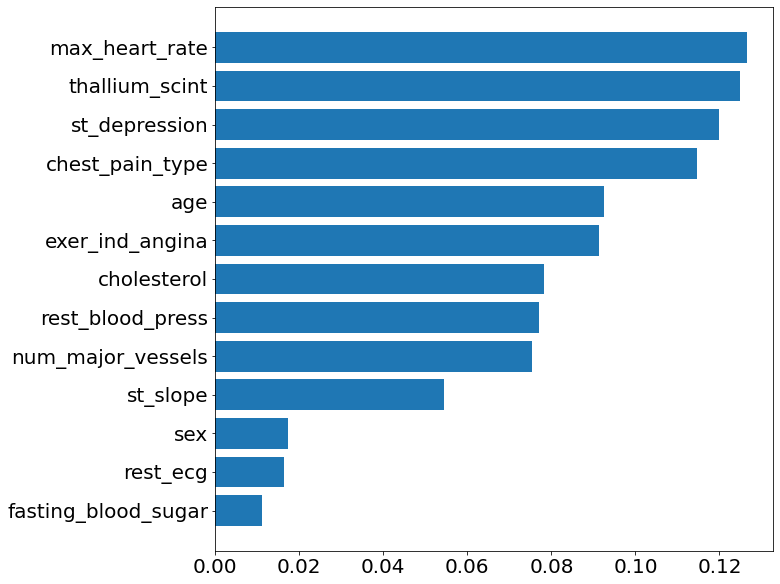

In [39]:
importances = np.array(rand_forest.feature_importances_)
feature_list = np.array(X.columns)
plot_feature_importance_dec(fit = importances, features = feature_list)

In [40]:
estimator = rand_forest.estimators_[1]

# Show the first few levels of the tree
_ = export_graphviz(estimator, out_file='tree.dot',
                feature_names = X.columns,
                class_names = ['No CAD', 'CAD'],
                rounded = True, proportion = True,
                label='root',
                precision = 2, filled = True);

In [41]:
_ = call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])
Image(filename = 'tree.png')

The Random Forest plot is interesting to analyse. Visually one can observe that ca disease (blue nodes) is evenly
spread throughout the leave nodes of the entire tree. A large proportion of the early ca disease nodes occur for
individuals with maximum heart rate < 150 and cholesterol >210. From here if ST depression >0.8 and one is male around
20% of the overall population is classified as having ca disease.
Likewise, a large proportion of the population with max heart rate >150 and chest pain < 3.5 is classified as not
having ca disease (orange nodes).
Another interesting factor is that Thallium Scintography is reported as the second most important feature. It does 
however not feature strongly in the Decision Tree. It is likely that strong cross-correlation with other strong 
features such as maximum heart rate causes the Thallium feature to only surface as a confirmatory feature at lower 
levels in the tree.

We now build our final Logistic Regression model with the variables selected.

StandardScaler()

AUC: 0.8694444444444445


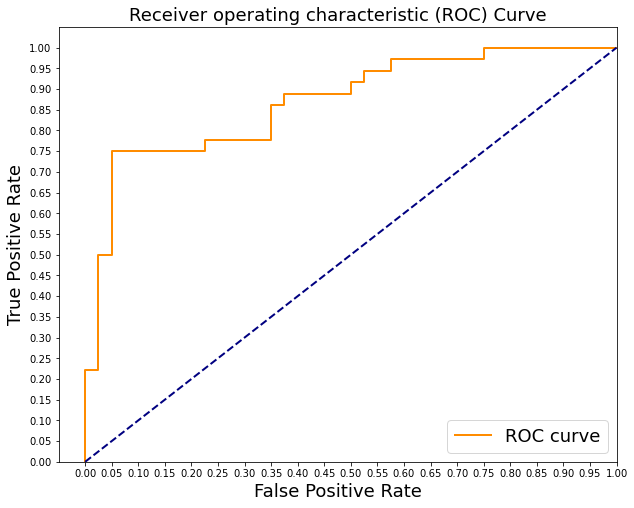

In [42]:
# Extract continuous and categorical variables for analysis.
X_fin_cat = df_fin_cat.loc[:,('sex', 'chest_pain_type', 'exer_ind_angina', 'st_slope', 'num_major_vessels', 'thallium_scint')]
X_fin_con = df_fin_con.loc[:,('max_heart_rate', 'st_depression')]
X_final = pd.concat([X_fin_cat, X_fin_con], axis=1)

X_train_fin, X_test_fin, y_train_fin, y_test_fin = train_test_split(X_final, y, random_state=0)

# Scale data
scaler = StandardScaler()

# Fit on training data set
scaler.fit(X_train_fin)
X_train_fin = scaler.transform(X_train_fin)

# Apply to test data
X_test_fin = scaler.transform(X_test_fin)

# Final model
logfin = LogisticRegression(fit_intercept = False)

# Probability scores for test set
y_score_fin = logfin.fit(X_train_fin, y_train_fin).decision_function(X_test_fin)

# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_fin, y_score_fin)

plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.87  
precision:			0.829 
sensitivity:			0.931

specificity:			0.809 
negative predictive value:	0.921

false positive rate:		0.191  
false negative rate:		0.069 
false discovery rate:		0.171


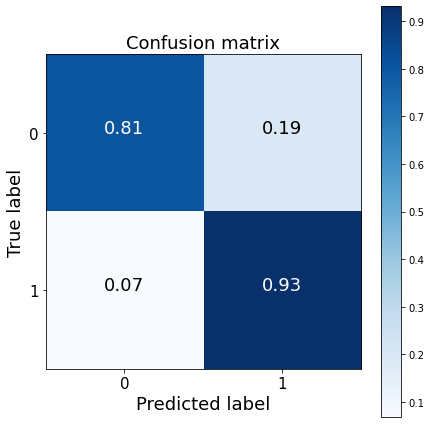

In [43]:
y_pred_fin = logfin.predict(X_test_fin)
# Accuracy before model parameter optimisation
cnf_matrix = confusion_matrix(y_pred_fin, y_test_fin)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

The accuracy results indicate that even though 5 variables were dropped, the model accuracy did not reduce by
a significant amount. We can therefore confidently deploy this model with the knowledge that it is both robust and
accurate.

<div class="alert alert-block alert-info">
<b>Build Model 2 - Multi-Layer Perceptron</b>
</div>

We can now build a Multi Layer Perceptron to compare with the Logistic Regression.

MSE before model optimisation

In [44]:
# Fit and check MSE before regularisation
reg = MLPClassifier(max_iter=50000, solver="adam", activation="tanh", hidden_layer_sizes=(5, 5), random_state=1)
reg.fit(X_train_fin, y_train_fin)

# Predict
y_pred_fin = reg.predict(X_test_fin)

# Accuracy before model parameter optimisation
accuracy_score(y_pred_fin, y_test_fin)

MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 5), max_iter=50000,
              random_state=1)

0.8289473684210527

We now optimise the NN architecture.

In [45]:
# Optimise numbers of nodes on both layers
validation_scores = {}
print("Nodes |Validation")
print("      | score")

for hidden_layer_size in [(i,j) for i in range(3,6) for j in range(3,6)]:

    reg = MLPClassifier(max_iter=1000000, hidden_layer_sizes=hidden_layer_size, random_state=1)

    score = cross_val_score(estimator=reg, X=X_train_fin, y=y_train_fin, cv=2)
    validation_scores[hidden_layer_size] = score.mean()
    print(hidden_layer_size, ": %0.5f" % validation_scores[hidden_layer_size])

Nodes |Validation
      | score
(3, 3) : 0.78850
(3, 4) : 0.82371
(3, 5) : 0.81490
(4, 3) : 0.80182
(4, 4) : 0.79728
(4, 5) : 0.80174
(5, 3) : 0.82386
(5, 4) : 0.78835
(5, 5) : 0.81490


In [46]:
# Check scores
print("The highest validation score is: %0.4f" % max(validation_scores.values()))
optimal_hidden_layer_size = [name for name, score in validation_scores.items()
                              if score==max(validation_scores.values())][0]
print("This corresponds to nodes", optimal_hidden_layer_size )

The highest validation score is: 0.8239
This corresponds to nodes (5, 3)


Now we optimise neural network regularisation parameter

 alpha  |  Accuracy
0.13534 |  0.8324018009625834
0.22313 |  0.832479428660146
0.36788 |  0.8369042074212079
0.60653 |  0.8369042074212079
1.00000 |  0.8369430212699891
1.64872 |  0.850217357553175
2.71828 |  0.8590281012265176
4.48169 |  0.8502561714019562
7.38906 |  0.8590281012265176
12.18249 |  0.8678776587486415
20.08554 |  0.8458313926408942
33.11545 |  0.6079413134606427


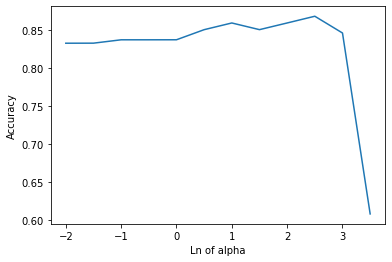

In [47]:
# Select range over which to find regularisation parameter - exponential used for even distribution of values
reg_par = [np.e**n for n in np.arange(-2,4,0.5)]

validation_scores = {}
print(" alpha  |  Accuracy")
for param in reg_par:
    reg = MLPClassifier(max_iter=1000000, solver="adam", activation="tanh", hidden_layer_sizes=optimal_hidden_layer_size, alpha=param,
                        random_state=1)
    score = cross_val_score(estimator=reg, X=X_train_fin, y=y_train_fin, cv=2, scoring="accuracy")
    validation_scores[param] = score.mean()
    print("%0.5f |  %s" % (param, score.mean()))

# Plot the accuracy function against regularisation parameter
plt.plot([np.log(i) for i in validation_scores.keys()], list(validation_scores.values()));
plt.xlabel("Ln of alpha");
plt.ylabel("Accuracy");

The highest cross-validation accuracy score and hence the value to use for the `alpha` parameter is as follows.

In [48]:
max_score = ([np.log(name) for name, score in validation_scores.items() if score==max(validation_scores.values())][0])

# Find lowest value.
print("The highest accuracy score is: %s" % (max(validation_scores.values())))
print("This corresponds to regularisation parameter e**%s" % max_score)

The highest accuracy score is: 0.8678776587486415
This corresponds to regularisation parameter e**2.5


MSE after regularisation

In [49]:
# Fit data with the best parameter
reg = MLPClassifier(max_iter=1000000, solver="adam", activation="tanh", hidden_layer_sizes=optimal_hidden_layer_size,
                    alpha=np.e**(2), random_state=1)

reg.fit(X_train_fin, y_train_fin)

# Predict
y_pred = reg.predict(X_test_fin)

# Accuracy after model parameter optimisation
accuracy_score(y_pred_fin, y_test_fin)

MLPClassifier(activation='tanh', alpha=7.3890560989306495,
              hidden_layer_sizes=(5, 3), max_iter=1000000, random_state=1)

0.8289473684210527

<div class="alert alert-block alert-info">
<b>Analysis of results</b>
</div>

Plot response curves

In [50]:
# Create X_design_vec, which contains the median of each respective column
X_design = X_final.copy()
X_design_vec = pd.DataFrame(X_design.median()).transpose()
X_design_vec.head()

,sex,chest_pain_type,exer_ind_angina,st_slope,num_major_vessels,thallium_scint,max_heart_rate,st_depression
0,1.0,3.0,0.0,2.0,0.0,3.0,153.0,0.8


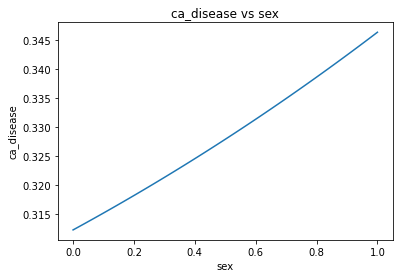

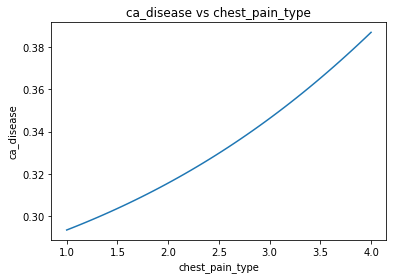

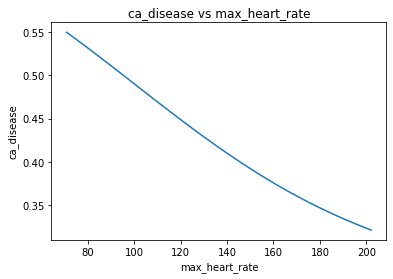

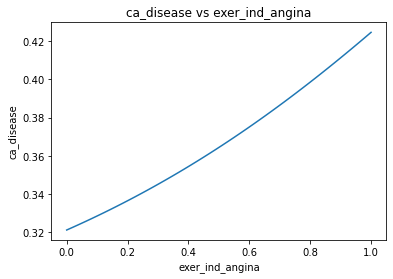

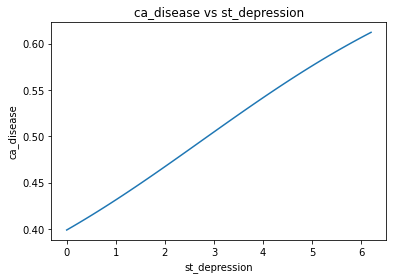

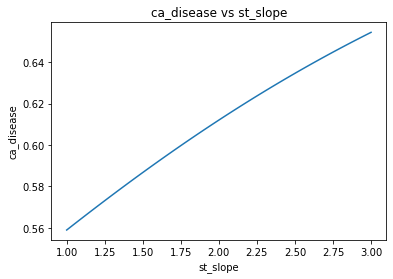

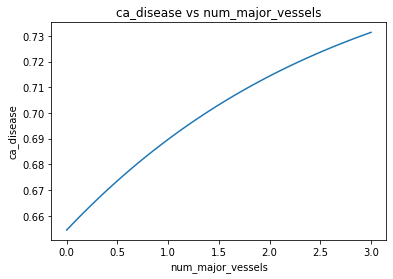

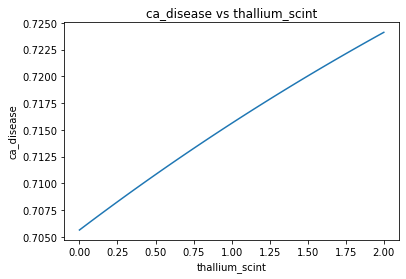

In [51]:
names_num = ('sex', 'chest_pain_type', 'max_heart_rate', 'exer_ind_angina', 'st_depression', 'st_slope', 'num_major_vessels', 'thallium_scint')

for variable in names_num:
    # Set up a sequence for response variable to plot
    min_res = min(X.loc[:,variable])
    max_res = max(X.loc[:,variable])
    seq = np.linspace(start=min_res,stop=max_res,num=50)

    # Set up a list of moving resultants to plot
    to_predict = []
    for result in seq:
        X_design_vec.loc[0,variable] = result
        to_predict.append(X_design_vec.copy())

    # Convert back to dataframe
    to_predict = pd.concat(to_predict)

    # Scale and predict
    to_predict = scaler.transform(to_predict)
    predictions = reg.predict_proba(to_predict)

    # Plot
    _ = plt.plot(seq,predictions[:,1])
    _ = plt.xlabel(variable)
    _ = plt.ylabel("ca_disease")
    _ = plt.title("ca_disease vs " + variable)
    plt.show();

Our model is accurate enough to capture the directly proportionate relationship between several response variables
(in order of strength of association, based on response curve output):

- thallium_scint
- num_major_vessels
- st_slope
- st_depression
- exer_ind_angina
- chest_pain_type
- sex

and the inversely proportional relationship between:

- max_heart_rate

and the outcome of confirmed Coronary Artery Disease. This is a positive outcome, as it means the model as applied
to the validation dataset managed to capture the underlying signals in the data. We can therefore conclude that the
model generalises well and that its accuracy is sufficiently high for this model to be used based on the features
captured.

This makes sense if one takes into account that the first two variables:

- thallium_scint: Arteries found to be: 1. Normal 2. Reversible defect and 3. Fixed defect
- num_major_vessels: Number of major vessels (0-3) coloured by fluoroscopy

are by nature close to the definition of Coronary Artery Disease itself.

Accuracy analysis

AUC: 0.8236111111111112


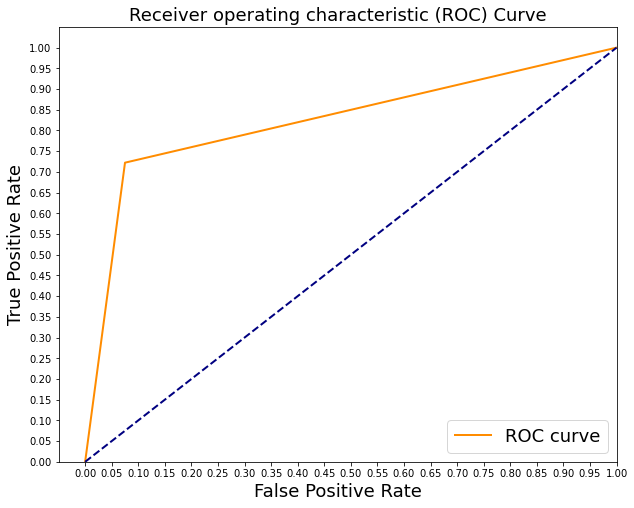

In [52]:
# False positive Rate and true positive rate
fpr_roc, tpr_roc, thresholds = roc_curve(y_test, y_pred)
plot_roc_curve(fpr = fpr_roc, tpr = tpr_roc)

Normalized confusion matrix

accuracy:			0.842  
precision:			0.808 
sensitivity:			0.897

specificity:			0.787 
negative predictive value:	0.884

false positive rate:		0.213  
false negative rate:		0.103 
false discovery rate:		0.192


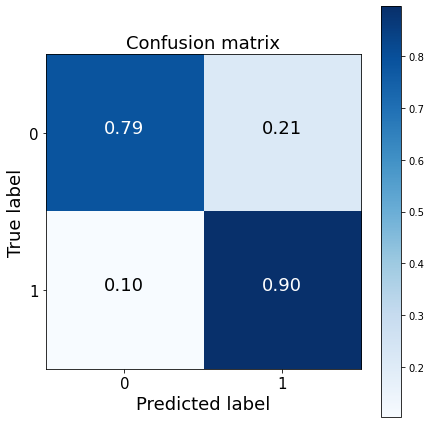

In [53]:
cnf_matrix = confusion_matrix(y_pred, y_test)
plot_confusion_matrix(cnf_matrix, classes=[0,1], normalize=True)

<div class="alert alert-block alert-info">
<b>Conclusion</b>
</div>

Given the similar levels of accuracy that both the Logistic and MLP models attained it will be up to clinical decision
makers to decide on the utility of these approaches. Given the confidence in the Gold Standard i.e. Angiography and the
consequences of incorrect diagnosis, in my mind it is unlikely that a test resulting in a sensitivity of approximately 90% or less will be considered as a replacement.
An understanding of the factors contributing to a positive Angiogram test would however assist clinicians in deciding
when an Angiogram might be indicated and what the likely outcome would be. This could assist in early intervention,
workup and planning. As I understand it there are problems in some settings with too many Angiograms being performed which could result in poorer patient care and outcomes. 
This analysis identified the 8 most important features to consider which are: thallium_scint, num_major_vessels,
st_slope, st_depression, max_heart_rate, exer_ind_angina, chest_pain_type and sex.